# Convolutional Neural Network (CNN) Classification - Fashion MNIST

## Project Overview

This project builds a CNN to classify Fashion-MNIST images.

## 1. Import Required Libraries

Import required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
tf.keras.utils.set_random_seed(42)
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report,confusion_matrix

## 2. Load Dataset

Load Fashion-MNIST.

In [2]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
print(x_train.shape,x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)


## 3. Explore Dataset

Visualize sample images.

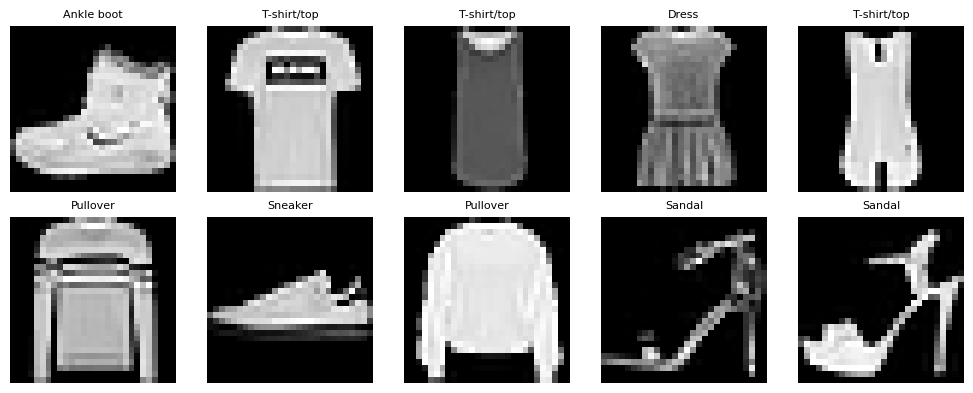

[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


In [3]:
plt.figure(figsize=(10,4))
for i in range(10):
 plt.subplot(2,5,i+1);plt.imshow(x_train[i],cmap='gray');plt.title(class_names[y_train[i]],fontsize=8);plt.axis('off')
plt.tight_layout();plt.show()
print(np.bincount(y_train))

## 4. Preprocess Images

Normalize and reshape.

In [4]:
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
x_train=x_train.reshape(-1,28,28,1);x_test=x_test.reshape(-1,28,28,1)
y_train_cat=to_categorical(y_train,10);y_test_cat=to_categorical(y_test,10)

## 5. Build CNN Model

Create CNN.

In [5]:
model=Sequential([Input(shape=(28,28,1)),Conv2D(32,(3,3),activation='relu'),MaxPooling2D((2,2)),Conv2D(64,(3,3),activation='relu'),MaxPooling2D((2,2)),Flatten(),Dense(128,activation='relu'),Dropout(0.3),Dense(10,activation='softmax')])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

Train with early stopping.

In [6]:
early=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history=model.fit(x_train,y_train_cat,validation_split=0.2,epochs=20,batch_size=64,callbacks=[early],verbose=1)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7921 - loss: 0.5686 - val_accuracy: 0.8653 - val_loss: 0.3796
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8658 - loss: 0.3702 - val_accuracy: 0.8803 - val_loss: 0.3269
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8826 - loss: 0.3220 - val_accuracy: 0.8827 - val_loss: 0.3093
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8939 - loss: 0.2910 - val_accuracy: 0.8942 - val_loss: 0.2868
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9034 - loss: 0.2658 - val_accuracy: 0.8948 - val_loss: 0.2793
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9094 - loss: 0.2480 - val_accuracy: 0.9028 - val_loss: 0.2708
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9150 - loss: 0.2284 - val_accuracy: 0.9003 - val_loss: 0.2660
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9216 - loss: 0.2136 - val

## 7. Training Curves

Plot curves.

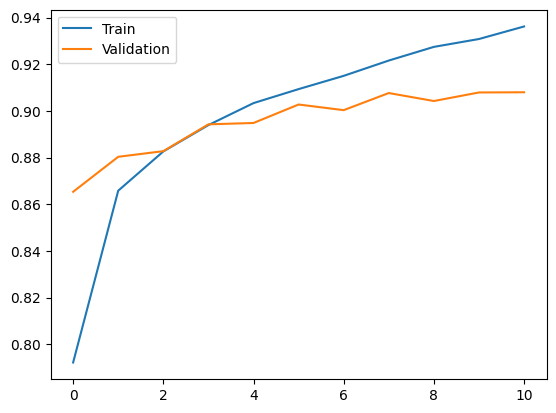

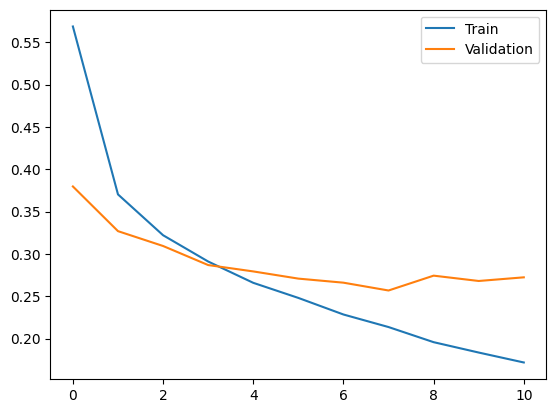

In [7]:
plt.plot(history.history['accuracy'],label='Train');plt.plot(history.history['val_accuracy'],label='Validation');plt.legend();plt.show()
plt.plot(history.history['loss'],label='Train');plt.plot(history.history['val_loss'],label='Validation');plt.legend();plt.show()

## 8. Evaluate Model

Evaluate.

In [8]:
loss,acc=model.evaluate(x_test,y_test_cat,verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {acc:.4f}')

Test Loss: 0.2669
Test Accuracy: 0.9045


## 9. Classification Report

Generate report.

In [9]:
pred=model.predict(x_test,verbose=0)
pred_labels=np.argmax(pred,axis=1)
print(classification_report(y_test,pred_labels,target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.80      0.85      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.83      0.87      0.85      1000
       Dress       0.90      0.93      0.91      1000
        Coat       0.88      0.83      0.85      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.70      0.76      0.73      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.91     10000
weighted avg       0.91      0.90      0.91     10000



## 10. Confusion Matrix

Visualize matrix.

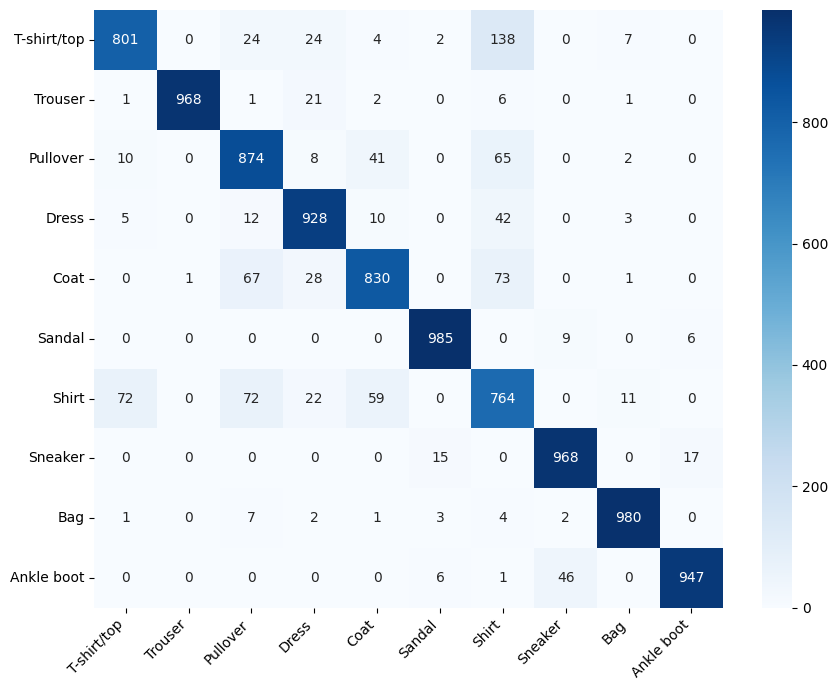

In [10]:
cm=confusion_matrix(y_test,pred_labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xticks(rotation=45,ha='right');plt.yticks(rotation=0);plt.tight_layout();plt.show()

## 11. Misclassified Images

Display misclassified samples.

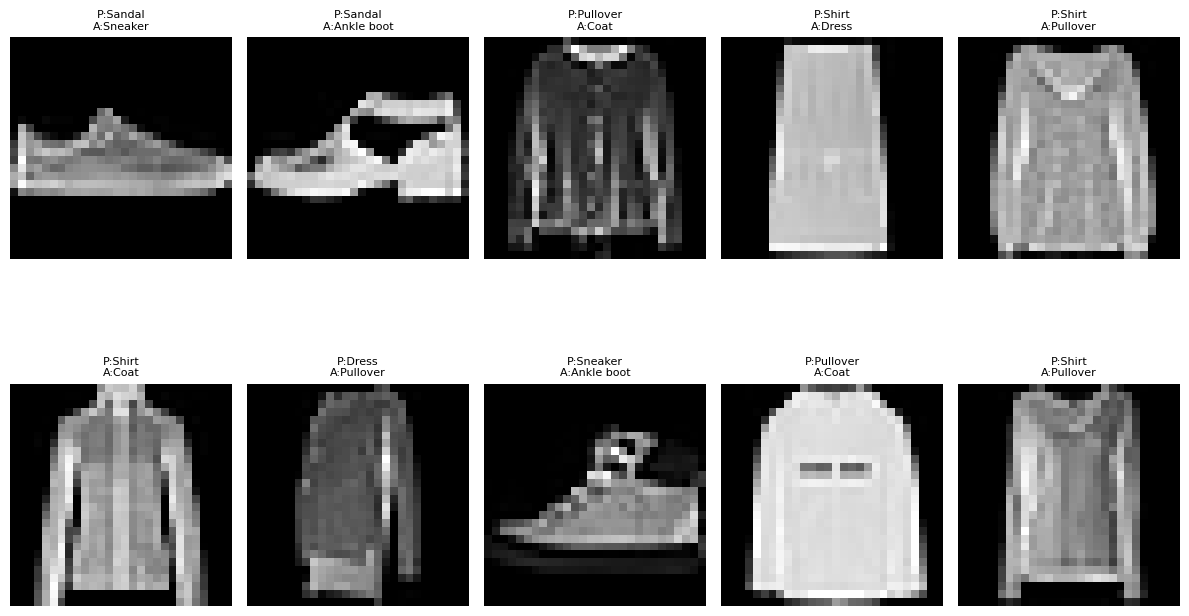

In [11]:
mis=np.where(pred_labels!=y_test)[0]
plt.figure(figsize=(12,8))
for i,idx in enumerate(mis[:10]):
 plt.subplot(2,5,i+1);plt.imshow(x_test[idx].reshape(28,28),cmap='gray');plt.title(f'P:{class_names[pred_labels[idx]]}\nA:{class_names[y_test[idx]]}',fontsize=8);plt.axis('off')
plt.tight_layout();plt.show()

## 12. Key Findings

- The Convolutional Neural Network achieved a **90.45%** test accuracy on the Fashion MNIST dataset, indicating strong performance on unseen images.
- Training and validation accuracy improved consistently throughout the training process, with only a small gap between them, suggesting that the model generalized well without significant overfitting.
- The classification report showed high precision and recall for visually distinct classes such as Trouser, Sneaker, Sandal, and Bag, while most prediction errors occurred between similar clothing categories including Shirt, T-shirt/top, Pullover, and Coat.
- The confusion matrix confirmed that the model learned meaningful visual features, with misclassifications largely concentrated among classes that share similar shapes and textures rather than being randomly distributed.

## 13. Conclusion

In this project, a Convolutional Neural Network was developed to classify images from the Fashion MNIST dataset. After preprocessing the data and training the model with early stopping, the final model achieved a **90.45%** test accuracy while maintaining stable validation performance throughout training. The evaluation results show that the network was able to learn representative image features for most clothing categories, with the remaining errors primarily occurring between visually similar classes. Overall, the project demonstrates a complete deep learning workflow, from data preparation and model development to performance evaluation and result interpretation.